In [1]:

import os, sys
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
from scipy.interpolate import griddata
import pyproj
import h5py
from netCDF4 import Dataset
import pandas as pd


In [2]:
fname= 'C:/Projects/IrrigationEU/Puglia_exp/DATA/ERA5_Land_total_precipitation_Foggia.nc'
R = Dataset('C:/Projects/IrrigationEU/Puglia_exp/DATA/ERA5_Land_total_precipitation_Foggia.nc','r')
print(R.variables.keys())
print(R.variables['valid_time'])
t = R['valid_time'][:]
tp =R['tp'][:,:,:]
rlon = R['longitude'][:,]
rlat = R['latitude'][:,]
tp_mm = tp * 1000
R.close()

dict_keys(['number', 'valid_time', 'latitude', 'longitude', 'expver', 'tp'])
<class 'netCDF4._netCDF4.Variable'>
int64 valid_time(valid_time)
    long_name: time
    standard_name: time
    units: seconds since 1970-01-01
    calendar: proleptic_gregorian
unlimited dimensions: 
current shape = (3653,)
filling on, default _FillValue of -9223372036854775806 used


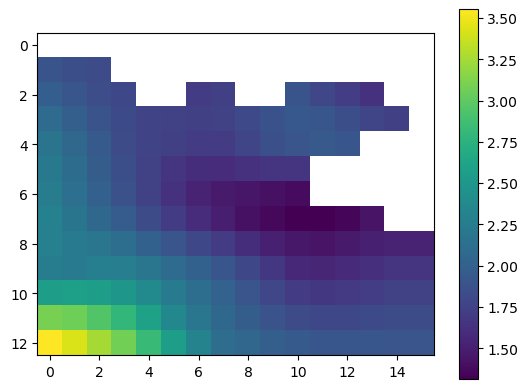

In [3]:
plt.imshow(np.nanmean(tp_mm,axis=0))
plt.colorbar()


In [4]:
rLONLAT= np.array(np.meshgrid(rlon,rlat))

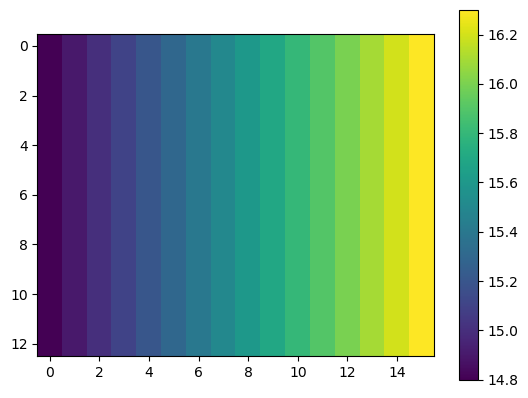

In [5]:
plt.imshow(rLONLAT[0,:,:])
plt.colorbar()

In [6]:
tt = [dt.datetime(1970,1,1)+ dt.timedelta(seconds=int(i)) for i in t]

In [7]:
r_flat = np.empty((tp_mm.shape[0], tp_mm.shape[1]*tp_mm.shape[2]))
for i in range(r_flat.shape[0]):
    r_flat[i,:] = tp_mm[i,:,:].reshape(tp_mm.shape[1]*tp_mm.shape[2])

In [8]:
R_dataframe=pd.DataFrame(r_flat, index = tt)
R_dataframe_cut=R_dataframe[dt.datetime(2018,1,1):dt.datetime(2025,1,1)]

In [9]:
R_dataframe_cut

,0,1,2,3,4,5,6,7,8,9,...,198,199,200,201,202,203,204,205,206,207
2018-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.012890,0.001714,0.001714,0.000715,0.000000,0.000000,0.000000,0.001207,0.001714,0.001252
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.666451,0.755349,0.618467,0.489154,0.397244,0.388229,0.506127,0.626513,0.679129,0.637764
2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.300478,4.435750,5.172285,5.900982,6.450507,6.565857,5.999583,5.407202,5.110669,5.141395
2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.573510,0.514859,0.816935,1.108015,1.365000,1.573557,1.708025,1.847798,1.964444,2.081180
2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.428894,0.418791,0.392491,0.364774,0.330725,0.279182,0.198761,0.115240,0.057557,0.030318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.800230,0.831165,0.790455,0.746109,0.688113,0.588216,0.425436,0.262507,0.145652,0.099756
2024-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.380504,0.433075,0.334758,0.238228,0.144917,0.079829,0.057596,0.029820,0.011939,0.002134
2024-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000298,0.000805,0.001431,0.001520,0.001073,0.000119,0.000000,0.000000
2024-12-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000858,0.000858,0.000858,0.000858,0.000858,0.000858,0.000858,0.000858,0.000858,0.000858


In [10]:
R_ARRAY = np.array(R_dataframe_cut)
RR = np.empty((R_ARRAY.shape[0],tp_mm.shape[1],tp_mm.shape[2]))
for i in range(RR.shape[0]):
    RR[i,:,:]=R_ARRAY[i,:].reshape(tp_mm.shape[1],tp_mm.shape[2])

In [11]:
RR.shape

(2557, 13, 16)

C:\Users\Jacopo\AppData\Local\Temp\ipykernel_28048\3415866733.py:1: RuntimeWarning: Mean of empty slice
  plt.imshow(np.nanmean(RR,axis=0))


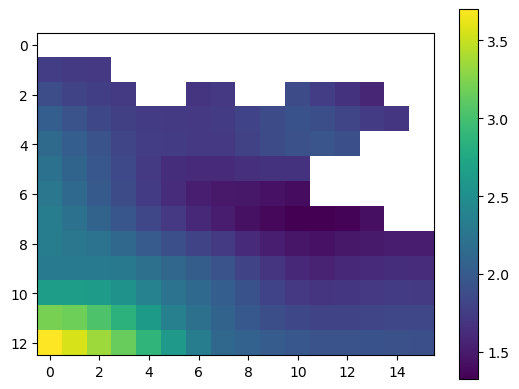

In [12]:
plt.imshow(np.nanmean(RR,axis=0))
plt.colorbar()


In [13]:
d2 = h5py.File(r'C:/Projects/IrrigationEU/Puglia_exp/ELAB/FOGGIA_GRID.hdf5','r')
lons = d2['lon'][:,:]
lats = d2['lat'][:,:]
d2.close()

In [14]:
RR.shape

(2557, 13, 16)

In [15]:
npointsold = rLONLAT.shape[1]*rLONLAT.shape[2]
npointsnew = lons.shape[0]*lons.shape[1]
coords = np.zeros((npointsold,2))
coords[:,0] = rLONLAT[0,:,:].flatten()
coords[:,1] = rLONLAT[1,:,:].flatten()
newcoords = np.zeros((npointsnew,2))
newcoords[:,0] = lons.flatten()
newcoords[:,1] = lats.flatten()
all_data_reshaped = np.empty((RR.shape[0], lons.shape[0]*lons.shape[1]))

for i in range(RR.shape[0]):
    all_data_reshaped[i,:] = griddata(coords, RR[i,:,:].reshape(RR.shape[1]*RR.shape[2]),newcoords, method='nearest')
    print ('DONE', i)

DONE 0
DONE 1
DONE 2
DONE 3
DONE 4
DONE 5
DONE 6
DONE 7
DONE 8
DONE 9
DONE 10
DONE 11
DONE 12
DONE 13
DONE 14
DONE 15
DONE 16
DONE 17
DONE 18
DONE 19
DONE 20
DONE 21
DONE 22
DONE 23
DONE 24
DONE 25
DONE 26
DONE 27
DONE 28
DONE 29
DONE 30
DONE 31
DONE 32
DONE 33
DONE 34
DONE 35
DONE 36
DONE 37
DONE 38
DONE 39
DONE 40
DONE 41
DONE 42
DONE 43
DONE 44
DONE 45
DONE 46
DONE 47
DONE 48
DONE 49
DONE 50
DONE 51
DONE 52
DONE 53
DONE 54
DONE 55
DONE 56
DONE 57
DONE 58
DONE 59
DONE 60
DONE 61
DONE 62
DONE 63
DONE 64
DONE 65
DONE 66
DONE 67
DONE 68
DONE 69
DONE 70
DONE 71
DONE 72
DONE 73
DONE 74
DONE 75
DONE 76
DONE 77
DONE 78
DONE 79
DONE 80
DONE 81
DONE 82
DONE 83
DONE 84
DONE 85
DONE 86
DONE 87
DONE 88
DONE 89
DONE 90
DONE 91
DONE 92
DONE 93
DONE 94
DONE 95
DONE 96
DONE 97
DONE 98
DONE 99
DONE 100
DONE 101
DONE 102
DONE 103
DONE 104
DONE 105
DONE 106
DONE 107
DONE 108
DONE 109
DONE 110
DONE 111
DONE 112
DONE 113
DONE 114
DONE 115
DONE 116
DONE 117
DONE 118
DONE 119
DONE 120
DONE 121
DONE 122
DON

In [16]:
all_data_reshapedd = np.zeros((all_data_reshaped.shape[0],lons.shape[0],lons.shape[1]))
for i in range(all_data_reshaped.shape[0]):
    all_data_reshapedd[i,:,:] = np.reshape(all_data_reshaped[i,:],(lons.shape[0],lons.shape[1]))
    
#all_data_reshapedd[all_data_reshapedd <0] = np.nan

C:\Users\Jacopo\AppData\Local\Temp\ipykernel_28048\1787152776.py:1: RuntimeWarning: Mean of empty slice
  mm = np.nanmean(all_data_reshapedd,axis = 0)


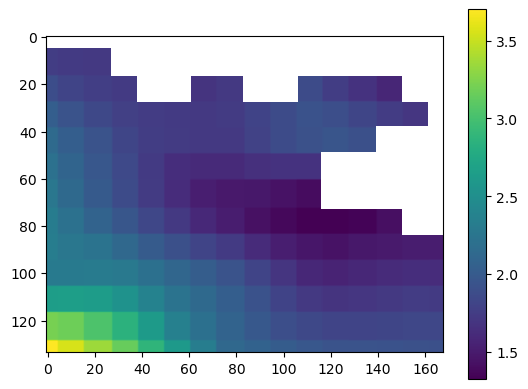

In [17]:
mm = np.nanmean(all_data_reshapedd,axis = 0)
plt.imshow(mm)
plt.colorbar()
plt.show()

In [18]:
# Saving the reprojected files to a hdf5 file
dout1 = h5py.File('ERA5_Land_rain_18_24_REGRIDDED.hdf5','w')
dout1.create_dataset('tp', data=all_data_reshapedd[:,:,:])

dout1.create_dataset('lon', data=lons)
dout1.create_dataset('lat', data=lats)
dout1.close()